Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import os
os.makedirs("outputs", exist_ok=True)

Load Dataset

In [2]:
# Load dataset from CSV
data = pd.read_csv("seattle-weather.csv")

print("Dataset Loaded Successfully")
print(data.head())
print("Shape:", data.shape)

Dataset Loaded Successfully
         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain
Shape: (1461, 6)


Data Preparation

In [3]:
# Drop date column (not useful for LDA)
data = data.drop("date", axis=1)

# Features and target
X = data.drop("weather", axis=1)
y = data["weather"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1461, 4)
Target shape: (1461,)


Handle Missing Values

In [4]:
print("Missing values before:\n", X.isnull().sum())

imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Missing values after:\n", X.isnull().sum())

Missing values before:
 precipitation    0
temp_max         0
temp_min         0
wind             0
dtype: int64
Missing values after:
 precipitation    0
temp_max         0
temp_min         0
wind             0
dtype: int64


Feature Distribution

<Figure size 640x480 with 0 Axes>

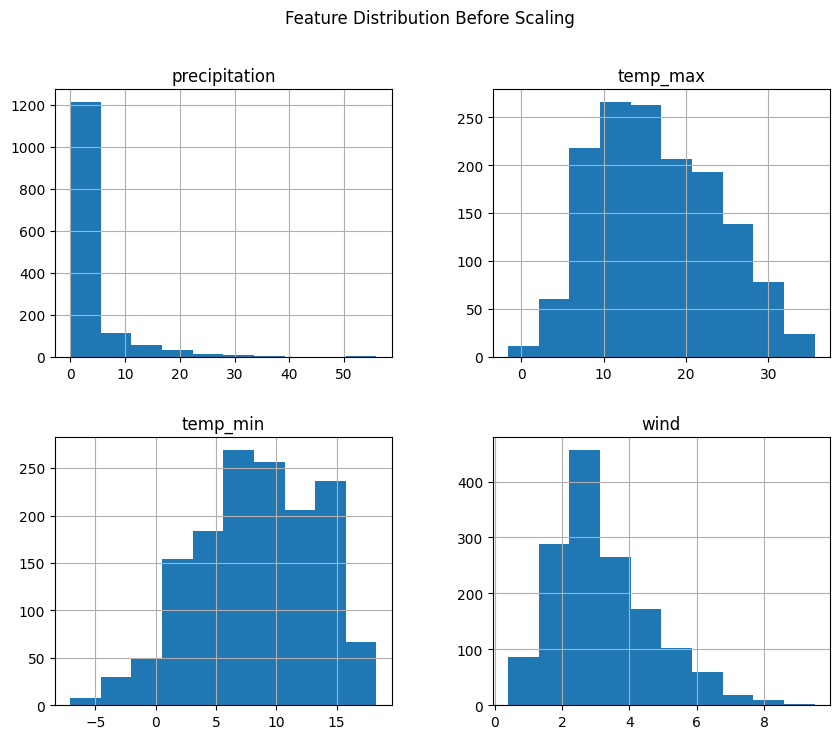

In [5]:
plt.figure()
X.hist(figsize=(10,8))
plt.suptitle("Feature Distribution Before Scaling")

plt.savefig("outputs/feature_distribution.png")
plt.show()

Encode Target Variable

In [6]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['drizzle' 'fog' 'rain' 'snow' 'sun']


Pairplot

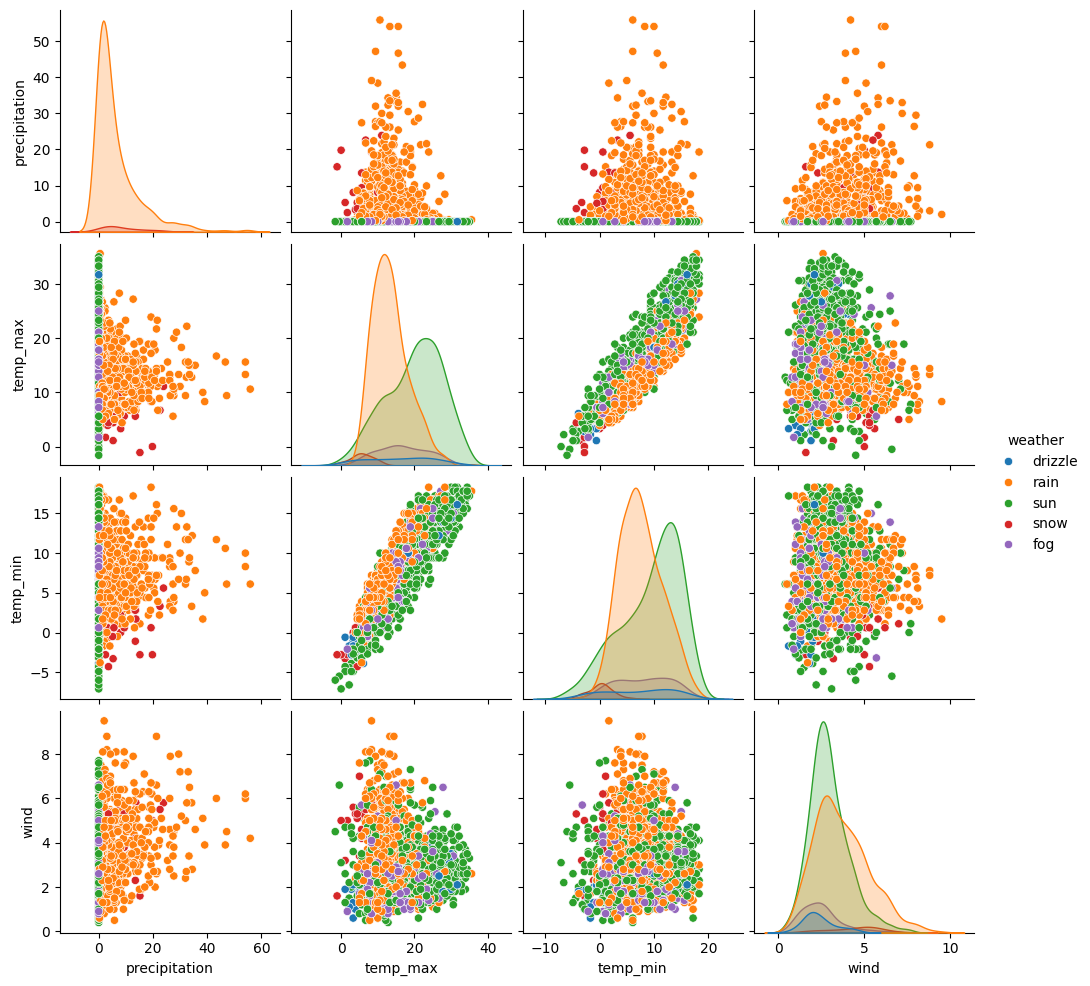

In [7]:
# Use original labels for better visualization
y_named = pd.Series(y, name="weather")

sns.pairplot(pd.concat([X, y_named], axis=1), hue="weather")

plt.savefig("outputs/pairplot.png")
plt.show()

Standardization

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Data Standardized")
X_scaled.head()

Data Standardized


,precipitation,temp_max,temp_min,wind
0,-0.453650,-0.495299,-0.644212,1.014980
1,1.178598,-0.794731,-1.082347,0.875833
2,-0.333852,-0.645015,-0.206077,-0.654780
3,2.586224,-0.576962,-0.524720,1.014980
4,-0.258978,-1.026111,-1.082347,1.989006


Apply LDA

In [9]:
n_classes = len(np.unique(y))
n_components = min(n_classes - 1, X_scaled.shape[1])

lda = LinearDiscriminantAnalysis(n_components=n_components)
X_lda = lda.fit_transform(X_scaled, y)

print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_lda.shape)

Original Shape: (1461, 4)
Reduced Shape: (1461, 4)


Explained Variance

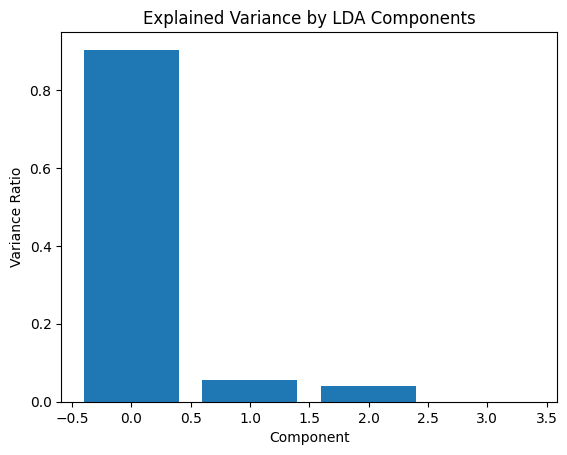

In [10]:
explained_var = lda.explained_variance_ratio_

plt.figure()
plt.bar(range(len(explained_var)), explained_var)
plt.title("Explained Variance by LDA Components")
plt.xlabel("Component")
plt.ylabel("Variance Ratio")

plt.savefig("outputs/lda_variance.png")
plt.show()

Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y, test_size=0.2, random_state=42, stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (1168, 4)
Test Shape: (293, 4)


Train LDA Classifier

In [12]:
classifier = LinearDiscriminantAnalysis()
classifier.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


Predictions

In [13]:
y_pred = classifier.predict(X_test)

print("Sample Predictions:", y_pred[:10])

Sample Predictions: ['sun' 'sun' 'sun' 'sun' 'sun' 'sun' 'sun' 'rain' 'rain' 'sun']


Accuracy

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

with open("outputs/accuracy.txt", "w") as f:
    f.write(f"Accuracy: {accuracy}\n")

Accuracy: 0.6962457337883959


Confusion Matrix

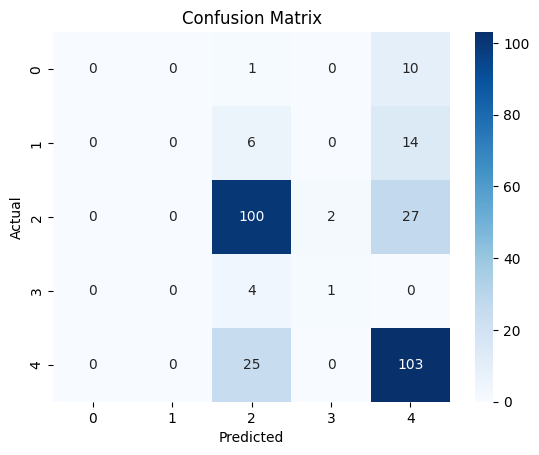

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("outputs/confusion_matrix.png")
plt.show()

Classification Report

In [16]:
report = classification_report(y_test, y_pred)
print(report)

with open("outputs/classification_report.txt", "w") as f:
    f.write(report)

              precision    recall  f1-score   support

     drizzle       0.00      0.00      0.00        11
         fog       0.00      0.00      0.00        20
        rain       0.74      0.78      0.75       129
        snow       0.33      0.20      0.25         5
         sun       0.67      0.80      0.73       128

    accuracy                           0.70       293
   macro avg       0.35      0.36      0.35       293
weighted avg       0.62      0.70      0.66       293



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


LDA Visualization

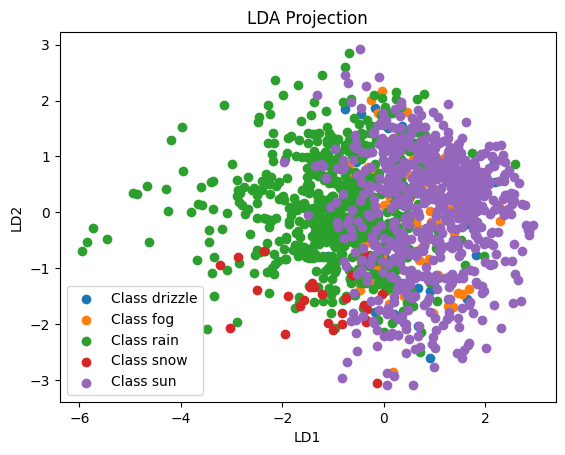

In [17]:
plt.figure()

for label in np.unique(y):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1] if X_lda.shape[1] > 1 else np.zeros_like(X_lda[y == label, 0]),
        label=f"Class {label}"
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection")

plt.legend()

plt.savefig("outputs/lda_projection.png")
plt.show()

Save Transformed Dataset

In [19]:
lda_df = pd.DataFrame(X_lda)
lda_df['target'] = y

lda_df.to_csv("outputs/lda_transformed_data.csv", index=False)

print("Transformed dataset saved successfully")

Transformed dataset saved successfully
